# Elaborazione immagini

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
from sklearn.linear_model import LinearRegression

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
FORMATO_COMUNE = "%Y-%m-%d %H:%M:%S"

def bilancia_timestamp_to_common(timestamp_unix, fmt=FORMATO_COMUNE):
    """
    Timestamp bilancia (Unix epoch) -> formato comune.
    Supporta secondi (10 cifre) e millisecondi (13 cifre).
    """
    ts = float(timestamp_unix)
    if ts > 1e12:  # millisecondi
        ts /= 1000.0
    return time.strftime(fmt, time.localtime(ts))


def image_timestamp_to_common(image_name_or_timestamp, fmt=FORMATO_COMUNE):
    """
    Timestamp immagini -> formato comune.
    Accetta:
    - 'frame_YYYYMMDD_HHMMSS.png'
    - 'YYYYMMDD_HHMMSS'
    - 'YYYY-MM-DD_HH-MM-SS' (nome cartella sessione)
    """
    s = str(image_name_or_timestamp)
    base = os.path.basename(s)

    m1 = re.search(r"(\d{8}_\d{6})", base)
    if m1:
        t = time.strptime(m1.group(1), "%Y%m%d_%H%M%S")
        return time.strftime(fmt, t)

    m2 = re.search(r"(\d{4}-\d{2}-\d{2}_\d{2}-\d{2}-\d{2})", base)
    if m2:
        t = time.strptime(m2.group(1), "%Y-%m-%d_%H-%M-%S")
        return time.strftime(fmt, t)

    raise ValueError("Formato timestamp immagine non riconosciuto")

In [4]:
# carica dati

reference_im_path = "data/raw/2026-04-27_12-23-55/reference_frame_20260427_122403.png"
imgs_folder = "data/raw/2026-04-27_12-24-03/images/"

imgs_paths = sorted([os.path.join(imgs_folder, f) for f in os.listdir(imgs_folder) if f.endswith('.png')])

imgs_timestamps = [os.path.basename(path).split(".")[0].split("_")[1] + "_" + os.path.basename(path).split(".")[0].split("_")[2] for path in imgs_paths]

img_timestamps = [image_timestamp_to_common(ts) for ts in imgs_timestamps]

In [5]:
ref_img = cv2.imread(reference_im_path, cv2.IMREAD_GRAYSCALE)
imgs = [cv2.imread(img_path, cv2.IMREAD_GRAYSCALE) for img_path in imgs_paths]

# moving average
window_size = 5
moving_avg_imgs = []
for i in range(len(imgs)):
    start_idx = max(0, i - window_size//2 + 1)
    end_idx = min(len(imgs), i + window_size//2 + 1)
    window_imgs = imgs[start_idx:end_idx]
    moving_avg_img = np.mean(window_imgs, axis=0).astype(np.uint8)
    moving_avg_imgs.append(moving_avg_img)

# differenza rispetto alla reference
diff_imgs = [cv2.absdiff(ref_img, img) for img in moving_avg_imgs]


In [6]:
roi_center = (350, 280)
roi_radius = 50

roi_mask = np.zeros_like(ref_img, dtype=np.uint8)
cv2.circle(roi_mask, roi_center, roi_radius, 255, -1)

roi_diff_imgs = [cv2.bitwise_and(diff_img, diff_img, mask=roi_mask) for diff_img in diff_imgs]

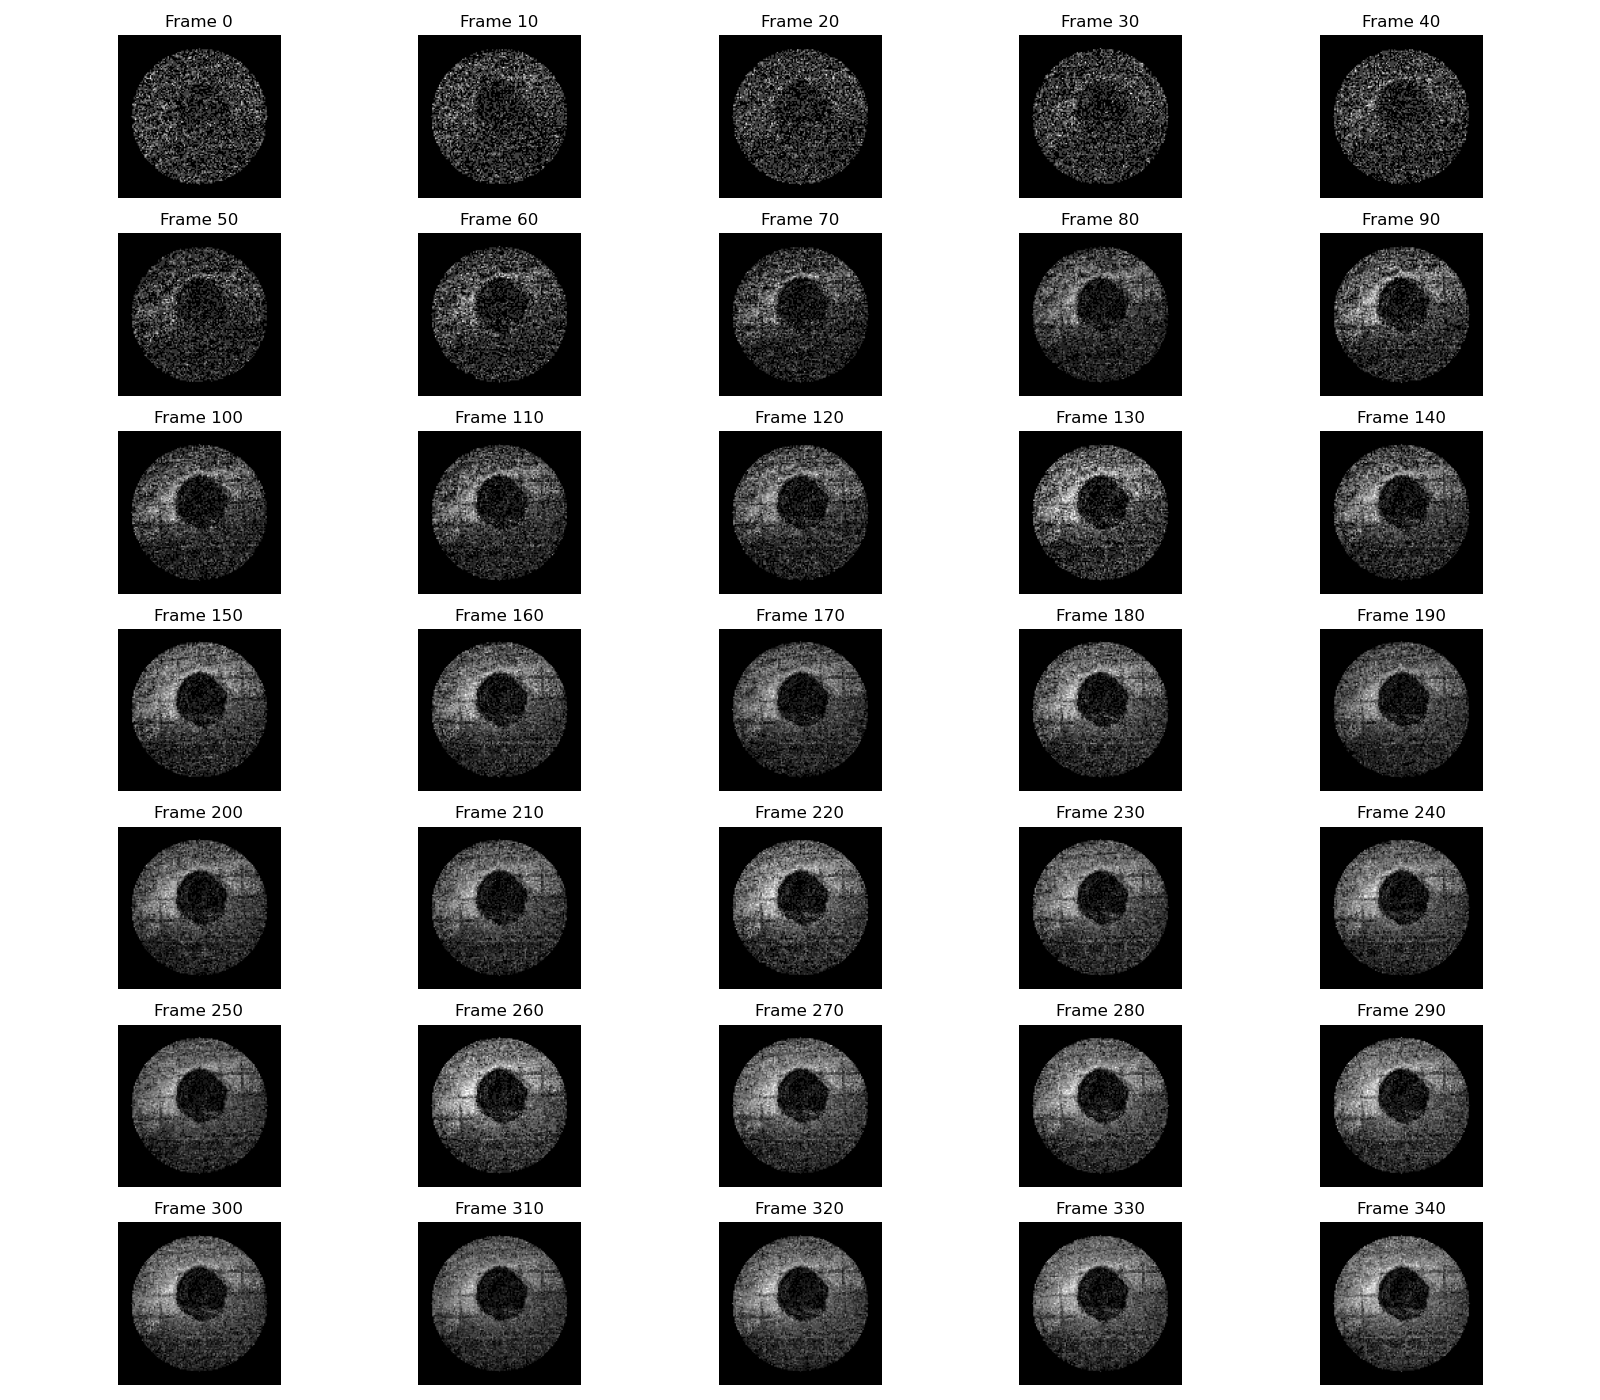

In [7]:
# visualizza le roi
step = 10
ncols = 5
nrows = (len(roi_diff_imgs) // step) // ncols + 1
plt.figure(figsize=(16, 2 * nrows))
for i in range(0, len(roi_diff_imgs), step):
    plt.subplot(nrows, ncols, i // step + 1)
    plt.imshow(roi_diff_imgs[i], cmap='gray')
    plt.title(f"Frame {i}")
    plt.axis('off')
    plt.xlim(roi_center[0] - roi_radius - step, roi_center[0] + roi_radius + step)
    plt.ylim(roi_center[1] - roi_radius - step, roi_center[1] + roi_radius + step)
plt.tight_layout()
plt.show()

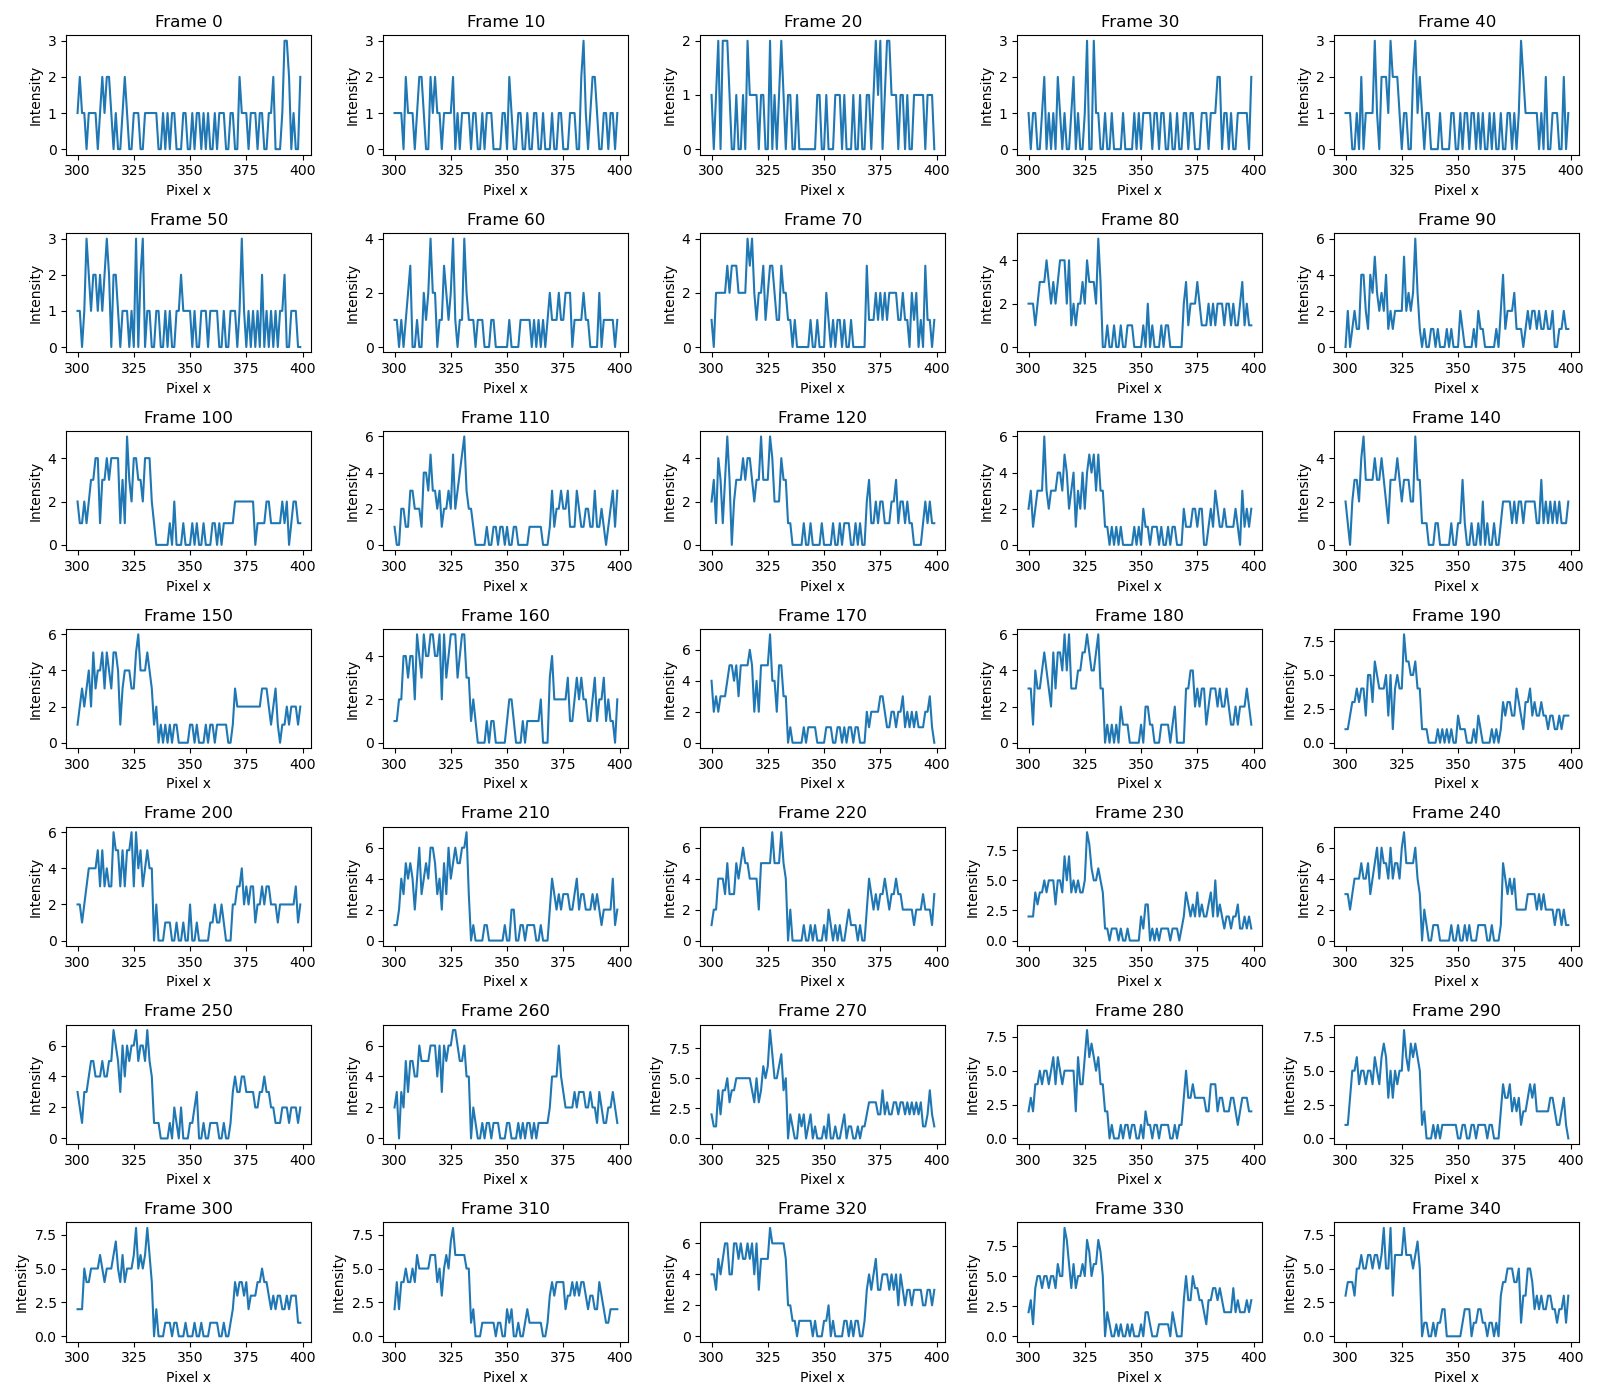

In [8]:
# estrai una retta orizzontale passante per il centro della ROI
line_length = 2 * roi_radius
h, w = roi_diff_imgs[0].shape

x1 = max(0, roi_center[0] - line_length // 2)
x2 = min(w, roi_center[0] + line_length // 2)
y1 = int(np.clip(roi_center[1], 0, h - 1))

fig, axs = plt.subplots(nrows, ncols, figsize=(16, 2 * nrows), squeeze=False)
axs = axs.flatten()

for i in range(0, len(roi_diff_imgs), step):

    if i > len(roi_diff_imgs):
        ax = axs[i // step]
        ax.axis('off')
        continue

    line_profile = roi_diff_imgs[i][y1, x1:x2]   # 1D
    ax = axs[i // step]
    ax.plot(np.arange(x1, x2), line_profile)
    ax.set_title(f"Frame {i}")
    ax.set_xlabel("Pixel x")
    ax.set_ylabel("Intensity")

plt.tight_layout()
plt.show()

In [9]:
means = [cv2.mean(roi_diff_img, mask=roi_mask)[0] for roi_diff_img in roi_diff_imgs]

smoothed_means = signal.savgol_filter(means, window_length=10, polyorder=2)
smoothed_means = means

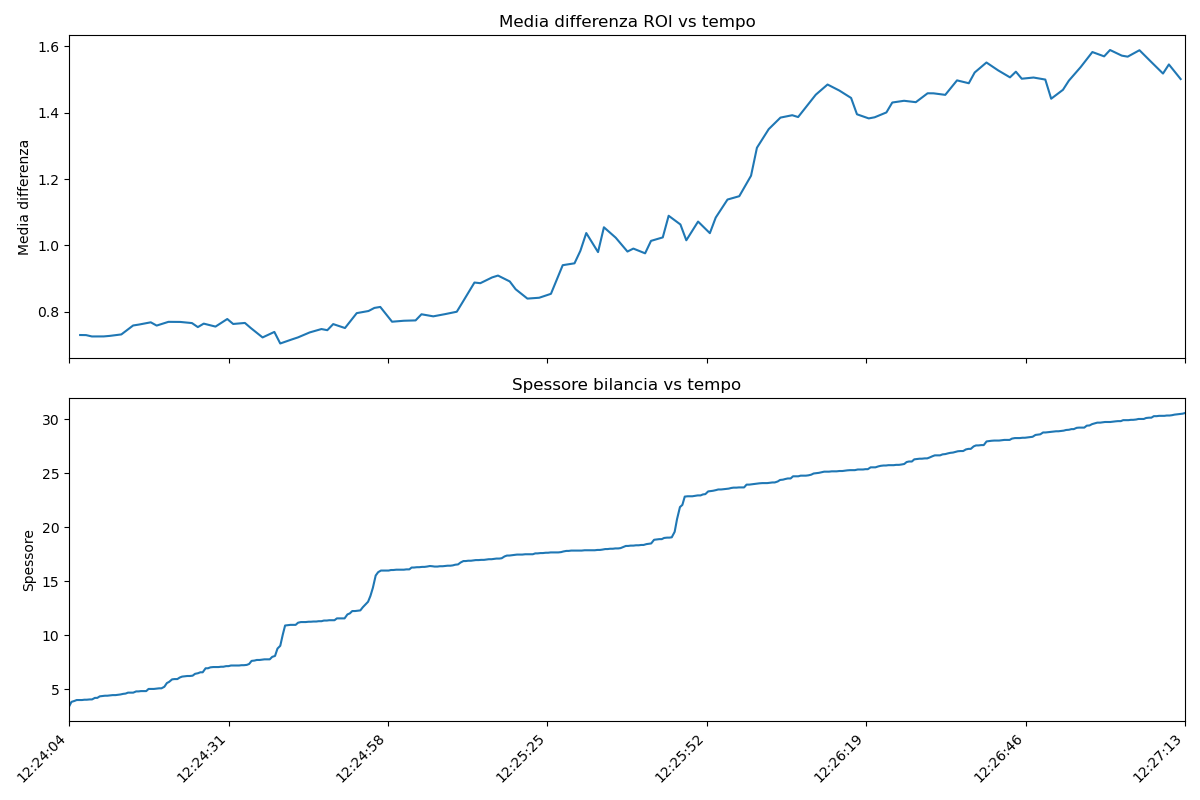

In [10]:

bilancia_data_path = "data/raw/2026-04-27_12-24-03/data/points.txt"
bilancia_data = np.loadtxt(bilancia_data_path, delimiter="\t")

# points.txt: timestamp, spessore, rate
timestamps = bilancia_data[:, 0].astype(float)
spessore = bilancia_data[:, 2].astype(float)
rates = bilancia_data[:, 1].astype(float)

# frame_YYYYMMDD_HHMMSS.png -> epoch Unix float
img_timestamps_epoch = np.array([
    time.mktime(time.strptime(ts, "%Y%m%d_%H%M%S")) for ts in imgs_timestamps
], dtype=float)

# intervallo temporale comune
t_start = max(float(img_timestamps_epoch.min()), float(timestamps.min()))
t_end = min(float(img_timestamps_epoch.max()), float(timestamps.max()))

if t_start >= t_end:
    raise ValueError("Nessuna sovrapposizione temporale tra immagini e bilancia")

img_mask = (img_timestamps_epoch >= t_start) & (img_timestamps_epoch <= t_end)
bil_mask = (timestamps >= t_start) & (timestamps <= t_end)

x_img = img_timestamps_epoch[img_mask]
y_img = np.asarray(smoothed_means, dtype=float)[img_mask]
x_bil = timestamps[bil_mask]
y_bil = spessore[bil_mask]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax1.plot(x_img, y_img, label="Media differenza ROI")
ax1.set_ylabel("Media differenza")
ax1.set_title("Media differenza ROI vs tempo")

ax2.plot(x_bil, y_bil, label="Spessore bilancia")
ax2.set_ylabel("Spessore")
ax2.set_title("Spessore bilancia vs tempo")

xticks = np.linspace(t_start, t_end, num=8)
ax2.set_xticks(xticks)
ax2.set_xticklabels(
    [time.strftime("%H:%M:%S", time.localtime(t)) for t in xticks],
    rotation=45,
    ha="right"
)

ax1.set_xlim(t_start, t_end)
plt.tight_layout()
plt.show()

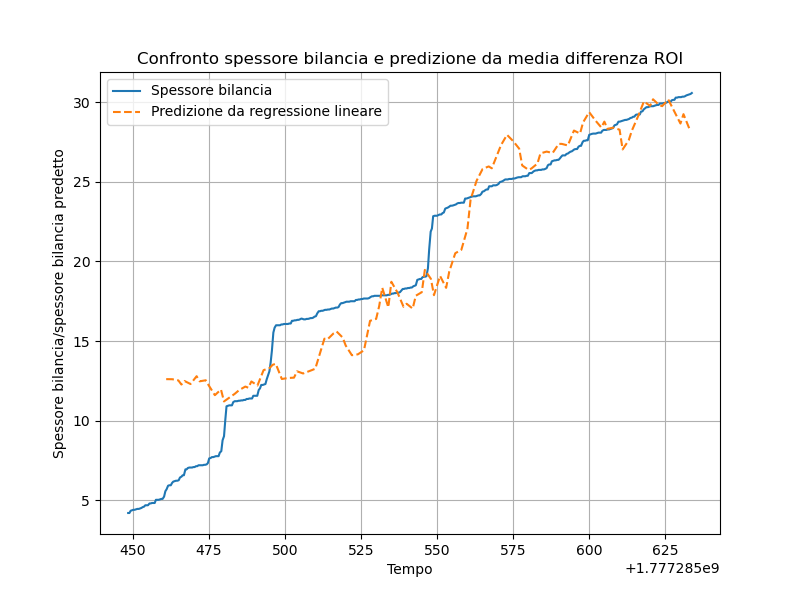

In [11]:
# taglia dei punti dall'inizio 
cut_size = 10
x_img = x_img[cut_size:]
y_img = y_img[cut_size:]
x_bil = x_bil[cut_size:]
y_bil = y_bil[cut_size:]


common_t = np.union1d(x_img, x_bil)
common_t = common_t[(common_t >= max(x_img.min(), x_bil.min())) &
                    (common_t <= min(x_img.max(), x_bil.max()))]

y_img_common = np.interp(common_t, x_img, y_img)
y_bil_common = np.interp(common_t, x_bil, y_bil)

model = LinearRegression()
fitted = model.fit(y_img_common.reshape(-1, 1), y_bil_common)

plt.figure(figsize=(8, 6))

plt.plot(x_bil, y_bil, label="Spessore bilancia")
plt.plot(common_t, model.predict(y_img_common.reshape(-1, 1)), label="Predizione da regressione lineare", linestyle="--")

plt.xlabel("Tempo")
plt.ylabel("Spessore bilancia/spessore bilancia predetto")
plt.title("Confronto spessore bilancia e predizione da media differenza ROI")
plt.legend()
plt.grid()
plt.show()